This is an unedited jupyter notebook

To plot Climate Finance Flows from a Financier Group (Developed Financiers or Financier Coalition*) to a Recipient Group (Developing Recipients or Developing Recipients Group**).

*Financier Coalition is G7+EU + Norway + South Korea + Australia - United States of America 
**Developing Recipients Group is Developing Recipients as per UNFCCC 1992 - China - Petroleum Rich States (South Korea, Russia, United Arab Emirates, Saudi Arabia, Qatar, Bahrain, Brunei, Kuwait)

/var/folders/n_/wz0dpmns379dn5s9v5qcpxww0000gn/T/ipykernel_15549/1060856479.py:231: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


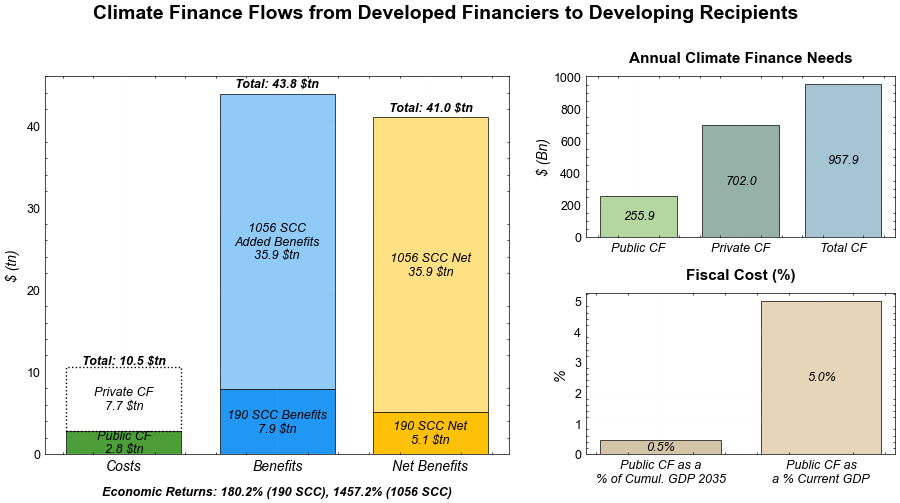

/var/folders/n_/wz0dpmns379dn5s9v5qcpxww0000gn/T/ipykernel_15549/1060856479.py:231: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


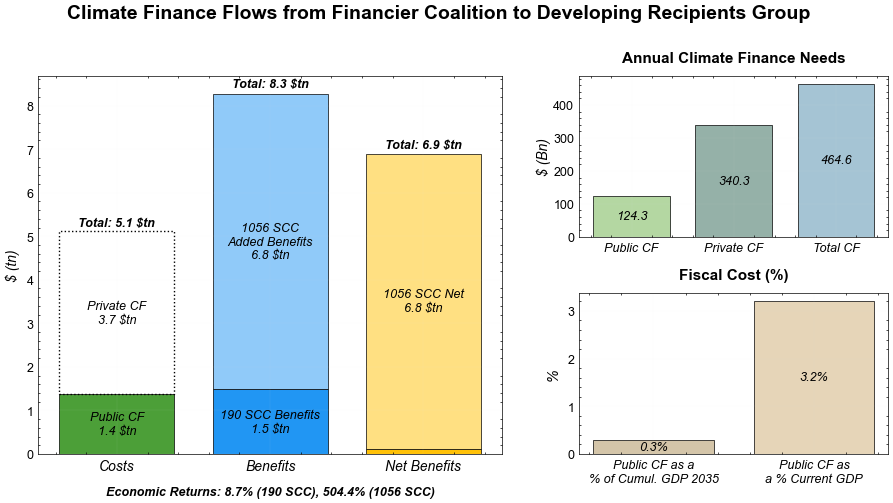


Plots have been saved to: /Users/yukthabhadane/Documents/Climate Finance Thesis/Paper Alissa Jan 2025/To Do 9 plots


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scienceplots

# Read the data
file_path = '/Users/yukthabhadane/Documents/Climate Finance Thesis/Policy Brief/v10_jupyter_COP29 Policy Brief_iso_scc_gdpc_gdo_histemi.xlsx'
df = pd.read_excel(file_path, sheet_name='For Plots')

# Set up the base style
plt.style.use(['science', 'nature', 'light'])

# Refined plot parameters
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'font.family': 'Arial',
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.linewidth': 0.5,
    'grid.linewidth': 0.3,
    'lines.linewidth': 0.8,
    'lines.markersize': 3,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.grid': True,
    'grid.alpha': 0.15,
    'grid.color': '#E5E5E5',
    'text.usetex': False,
})

def create_plots(data_series, variation_name, display_title=None):
    """
    Creates main plot with two smaller subplots on the right
    
    Parameters:
    data_series: DataFrame column containing data for the variation
    variation_name: Original name of the variation (column name)
    display_title: Custom title to display (if None, uses variation_name)
    """
    # Create figure with reduced dimensions
    fig = plt.figure(figsize=(10, 6))
    
    # More precise control over grid layout
    gs = plt.GridSpec(2, 2,
                     width_ratios=[1.5, 1],     # Control width ratio between main and right plots 
                     height_ratios=[1, 1],      # Control heights of right plots
                     left=0.1,                  # Left margin
                     right=0.95,                # Right margin
                     top=0.83,                  # Top margin (leave space for title)
                     bottom=0.2,                # Bottom margin increased for economic returns note
                     hspace=0.35,                # Height space between subplots
                     wspace=0.2)                # Width space between main and right plots
    
    # Create axes
    ax_main = fig.add_subplot(gs[:, 0])        # Main plot uses both rows
    ax_top_right = fig.add_subplot(gs[0, 1])   # Top right subplot
    ax_bottom_right = fig.add_subplot(gs[1, 1]) # Bottom right subplot
    
    # Set the title using the provided display_title or fall back to variation_name
    title_to_use = display_title if display_title is not None else variation_name
    fig.suptitle(f'Climate Finance Flows from {title_to_use}',
                y=0.95, fontsize=14, fontweight='bold')

    # Convert to trillion for main plot
    costs_data = {
        'Public': data_series.iloc[1],
        'Private': data_series.iloc[2],
        'Total': data_series.iloc[0]
    }
    
    benefits_data = {
        'Benefits_190': data_series.iloc[4],
        'Added_Benefits_1056': data_series.iloc[5],
        'Total': data_series.iloc[3]
    }
    
    net_benefits_data = {
        'Net_190': data_series.iloc[7],
        'Added_Net_1056': data_series.iloc[8],
        'Total': data_series.iloc[6]
    }

    # Calculate threshold (5% of maximum total)
    total_all = max(costs_data['Total'], benefits_data['Total'], net_benefits_data['Total'])
    threshold = 0.05 * total_all

    # MAIN PLOT
    bar_width = 0.75
    bar_positions = np.arange(3)
    
    # Helper function for labels
    def add_bar_label(ax, x, y, label, value, threshold=0):
        if value > threshold:
            ax.text(x, y, f'{label}\n{value:.1f} $tn',
                   ha='center', va='center', fontsize=9,
                   style='italic', zorder=5)

    # Costs bars
    ax_main.bar(bar_positions[0], costs_data['Public'], bar_width,
                color='#4C9F38', edgecolor='black', linewidth=0.5)
    ax_main.bar(bar_positions[0], costs_data['Private'], bar_width,
                bottom=costs_data['Public'], color='none',
                edgecolor='black', linewidth=1, linestyle=':')

    # Labels for costs with threshold
    if costs_data['Public'] > threshold:
        add_bar_label(ax_main, bar_positions[0], costs_data['Public']/2,
                     'Public CF', costs_data['Public'])
    if costs_data['Private'] > threshold:
        add_bar_label(ax_main, bar_positions[0],
                     costs_data['Public'] + costs_data['Private']/2,
                     'Private CF', costs_data['Private'])

    # Benefits bars
    ax_main.bar(bar_positions[1], benefits_data['Benefits_190'],
                bar_width, color='#2196F3', edgecolor='black', linewidth=0.5)
    ax_main.bar(bar_positions[1], benefits_data['Added_Benefits_1056'],
                bar_width, bottom=benefits_data['Benefits_190'],
                color='#90CAF9', edgecolor='black', linewidth=0.5)

    # Labels for benefits with threshold
    if benefits_data['Benefits_190'] > threshold:
        add_bar_label(ax_main, bar_positions[1], benefits_data['Benefits_190']/2,
                     '190 SCC Benefits', benefits_data['Benefits_190'])
    if benefits_data['Added_Benefits_1056'] > threshold:
        add_bar_label(ax_main, bar_positions[1],
                     benefits_data['Benefits_190'] + benefits_data['Added_Benefits_1056']/2,
                     '1056 SCC\nAdded Benefits', benefits_data['Added_Benefits_1056'])

    # Net Benefits bars
    ax_main.bar(bar_positions[2], net_benefits_data['Net_190'],
                bar_width, color='#FFC107', edgecolor='black', linewidth=0.5)
    ax_main.bar(bar_positions[2], net_benefits_data['Added_Net_1056'],
                bar_width, bottom=net_benefits_data['Net_190'],
                color='#FFE082', edgecolor='black', linewidth=0.5)

    # Labels for net benefits with threshold
    if net_benefits_data['Net_190'] > threshold:
        add_bar_label(ax_main, bar_positions[2], net_benefits_data['Net_190']/2,
                     '190 SCC Net', net_benefits_data['Net_190'])
    if net_benefits_data['Added_Net_1056'] > threshold:
        add_bar_label(ax_main, bar_positions[2],
                     net_benefits_data['Net_190'] + net_benefits_data['Added_Net_1056']/2,
                     '1056 SCC Net', net_benefits_data['Added_Net_1056'])

    # Add totals on top of each bar
    for i, total in enumerate([costs_data['Total'], benefits_data['Total'], net_benefits_data['Total']]):
        ax_main.text(bar_positions[i], total * 1.01,
                    f'Total: {total:.1f} $tn',
                    ha='center', va='bottom', fontsize=9, style='italic', fontweight='bold')

    # Add economic returns note at bottom
    returns_note = f'Economic Returns: {data_series.iloc[9]:.1f}% (190 SCC), {data_series.iloc[10]:.1f}% (1056 SCC)'
    ax_main.text(0.5, -0.1, returns_note,
                ha='center', va='center',
                transform=ax_main.transAxes,
                fontweight='bold', style='italic',
                fontsize=9)

    # Remove ticks
    ax_main.tick_params(length=0)
    ax_top_right.tick_params(length=0)
    ax_bottom_right.tick_params(length=0)

    # Customize main plot
    ax_main.set_ylabel('$ (tn)', style='italic', labelpad=5)
    ax_main.set_xticks(bar_positions)
    ax_main.set_xticklabels(['Costs', 'Benefits', 
                            'Net Benefits'], style='italic', fontsize=10)

    # RIGHT SUBPLOTS with muted colors
    # Annual Climate Finance (Top Right)
    annual_data = {
        'Public CF': data_series.iloc[11] * 1000,  # Convert to billion
        'Private CF': data_series.iloc[12] * 1000,
        'Total CF': data_series.iloc[13] * 1000
    }
    
    bar_positions_annual = np.arange(3)
    colors_annual = ['#B4D7A2', '#95B1A8', '#A5C4D4']  # Muted colors
    
    for i, (key, value) in enumerate(annual_data.items()):
        bar = ax_top_right.bar(bar_positions_annual[i], value, bar_width,
                              color=colors_annual[i], edgecolor='black',
                              linewidth=0.5)
        ax_top_right.text(bar_positions_annual[i], value/2,
                         f'{value:.1f}',
                         ha='center', va='center', fontsize=9,
                         style='italic')

    # Fiscal Cost (Bottom Right)
    fiscal_data = {
        'Inner Quantum/\nCumul. GDP': data_series.iloc[14],  # Already in percentage
        'Inner Quantum/\n2024 GDP': data_series.iloc[15]
    }
    
    bar_positions_fiscal = np.arange(2)
    colors_fiscal = ['#D4C5A9', '#E6D5B8']  # Muted colors
    
    for i, (key, value) in enumerate(fiscal_data.items()):
        if value > 0:
            bar = ax_bottom_right.bar(bar_positions_fiscal[i], value, bar_width,
                                    color=colors_fiscal[i], edgecolor='black',
                                    linewidth=0.5)
            ax_bottom_right.text(bar_positions_fiscal[i], value/2,
                               f'{value:.1f}%',
                               ha='center', va='center', fontsize=9,
                               style='italic')

    # Customize subplots
    ax_top_right.set_title('Annual Climate Finance Needs', pad=10, fontsize=11,
                          fontweight='bold')
    ax_top_right.set_ylabel('$ (Bn)', style='italic', labelpad=2)
    ax_top_right.set_xticks(bar_positions_annual)
    ax_top_right.set_xticklabels(['Public CF', 'Private CF', 'Total CF'],
                                fontsize=9, style='italic')


    ax_bottom_right.set_title('Fiscal Cost (%)', pad=10, fontsize=11,
                             fontweight='bold')
    ax_bottom_right.set_ylabel('%', style='italic', labelpad=5)
    ax_bottom_right.set_xticks(bar_positions_fiscal)
    ax_bottom_right.set_xticklabels(['Public CF as a\n% of Cumul. GDP 2035', 
                                    'Public CF as\na % Current GDP'],
                                   fontsize=9, style='italic')
    plt.tight_layout()
    
    return fig

# Create plots for specific variations only
selected_variations = [
    'Developed Financiers to Developing Recipients',
    'G7 + EU plus Norway, Switzerland, Australia, South Korea (excl. USA) to \nDeveloping Recipients (excl. China, Petroleum rich countries)'
]

# Define custom display titles for each variation
custom_titles = {
    'Developed Financiers to Developing Recipients': 'Developed Financiers to Developing Recipients',
    'G7 + EU plus Norway, Switzerland, Australia, South Korea (excl. USA) to \nDeveloping Recipients (excl. China, Petroleum rich countries)': 'Financier Coalition to Developing Recipients Group'
}

# Filter variations that exist in the dataframe
available_variations = [var for var in selected_variations if var in df.columns]

# Create output directory if it doesn't exist
import os
output_dir = '/Users/yukthabhadane/Documents/Climate Finance Thesis/Paper Alissa Jan 2025/To Do 9 plots'
os.makedirs(output_dir, exist_ok=True)

# Create plots and save them
for variation in available_variations:
    # Use custom title if available, otherwise use the original variation name
    display_title = custom_titles.get(variation, variation)
    fig = create_plots(df[variation], variation, display_title)
    
    # Clean filename by removing special characters and replacing spaces
    clean_filename = variation.replace('\n', ' ').replace('/', '_').replace('\\', '_')
    clean_filename = ''.join(c if c.isalnum() or c in (' ', '_', '-', '.') else '_' for c in clean_filename)
    clean_filename = clean_filename.strip()
    
    # Save the plot with high resolution
    filepath = os.path.join(output_dir, f"{clean_filename}.png")
    fig.savefig(filepath, dpi=300, bbox_inches='tight', pad_inches=0.1)
    
    plt.show()
    plt.close(fig)  # Clean up memory

print(f"\nPlots have been saved to: {output_dir}")

To plot economic returns to either Financier Group to decarbonise the selected 8 developing countries under SCC 190 and SCC 1056

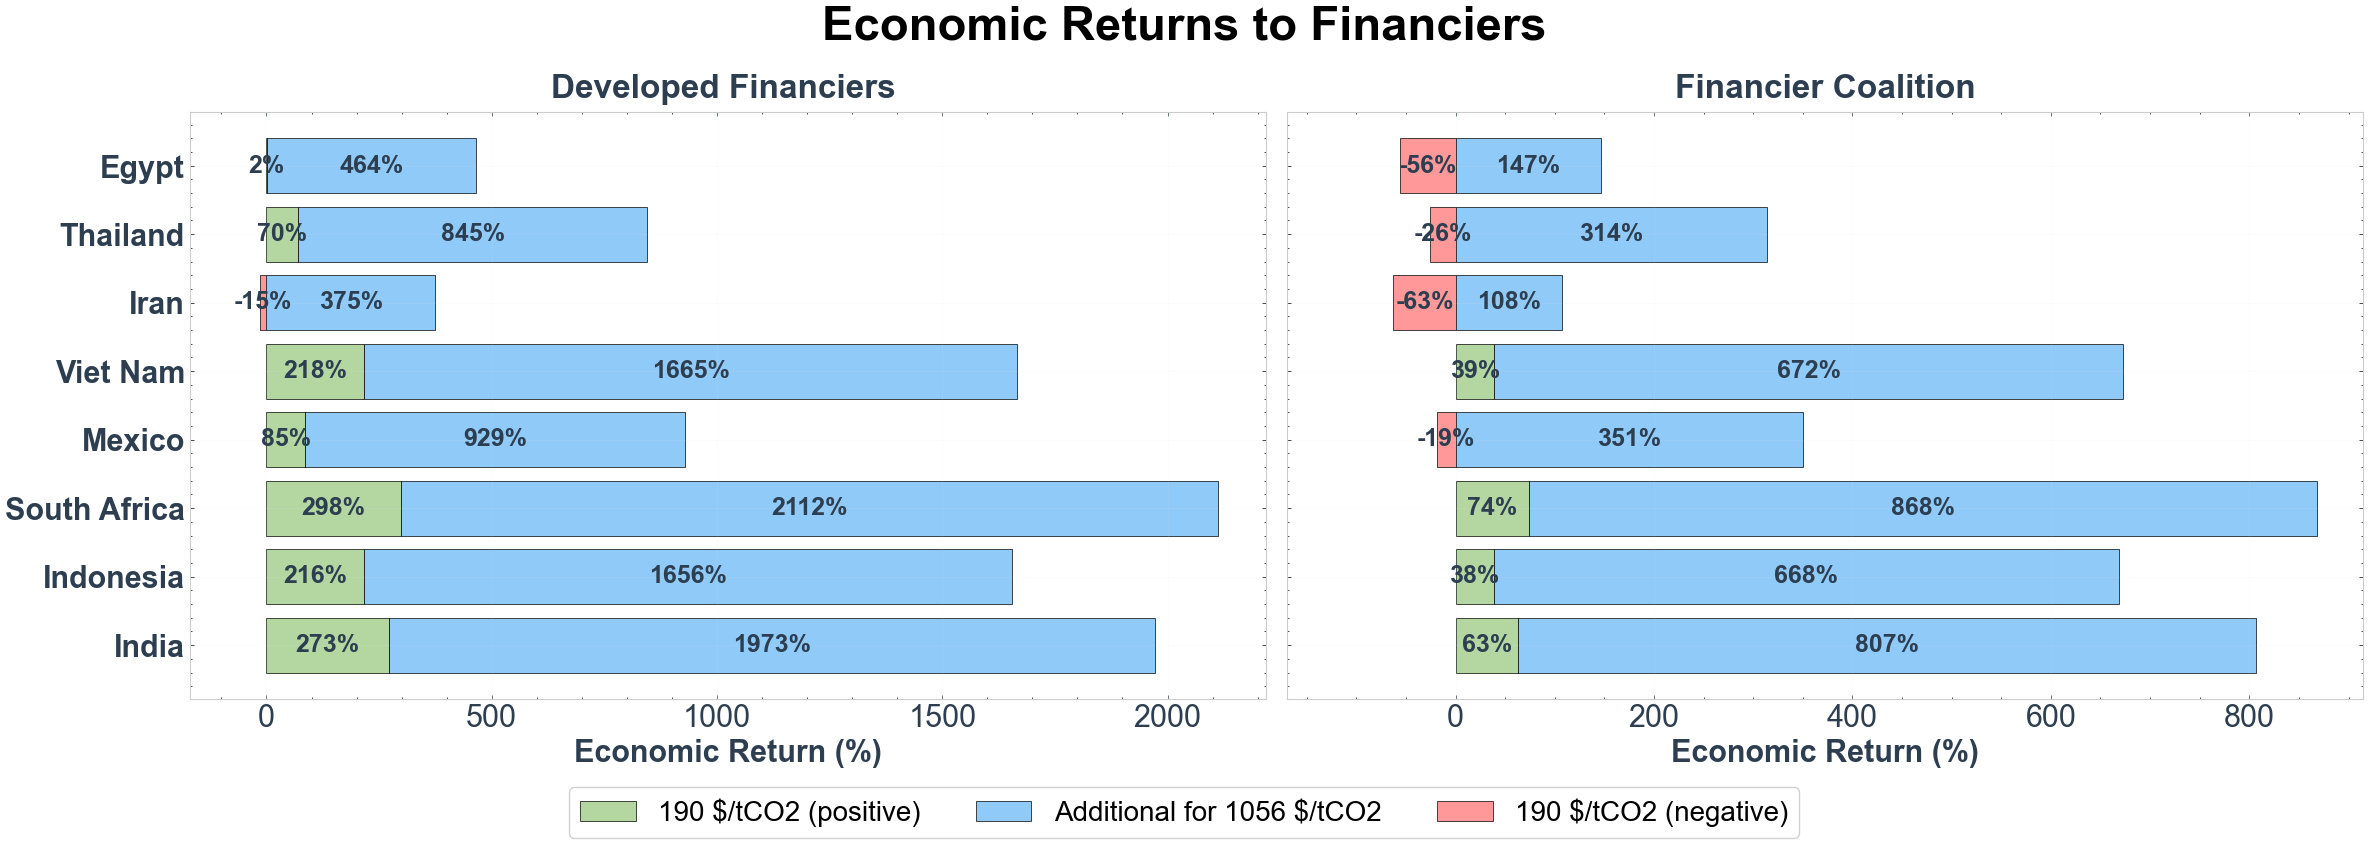

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scienceplots

# Set the style
plt.style.use(['science', 'nature', 'light'])

# Update plot parameters with larger fonts and elements
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'font.family': 'Arial',
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.2,
    'lines.markersize': 5,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.grid': True,
    'grid.alpha': 0.15,
    'grid.color': '#E5E5E5',
    'text.usetex': False,
})

# Read the Excel file
df = pd.read_excel("/Users/yukthabhadane/Documents/Climate Finance Thesis/Paper Alissa Jan 2025/Excel sheets/jupyter To Do 8 and 9 .xlsx", 
                   sheet_name="8 C _ Dev Financier Model")

# Define country order
country_order = ['India', 'Indonesia', 'South Africa', 'Mexico', 'Viet Nam', 'Iran', 'Thailand', 'Egypt']

def create_side_by_side_plots(df, country_order):
    # Create figure with two subplots side by side with increased size
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 8))
    
    # Updated color scheme with muted, pastel colors
    colors = {
        'positive_190': '#B4D7A2',     # Muted sage green (from reference)
        'negative_190': '#FF9999',     # soft red for negative returns
        'additional_1056': '#90CAF9',  # Muted blue (from reference)
        'muted_green': '#95B1A8',      # Additional muted green
        'text_dark': '#2C3E50',        # Dark color for primary text
        'text_light': '#FFFFFF'        # White for text on dark backgrounds
    }
    
    # Store legend handles and labels
    legend_handles = []
    legend_labels = []
    
    # Process each financier group
    for idx, (ax, group) in enumerate(zip([ax1, ax2], df['Financier Group '].unique())):
        # Get data for this group and order it
        group_data = df[df['Financier Group '] == group]
        
        y_pos = np.arange(len(country_order))
        returns_190 = []
        returns_1056 = []
        
        # Collect data in order
        for country in country_order:
            country_data = group_data[group_data['Country '] == country].iloc[0]
            returns_190.append(country_data['Return % 190 SCC'])
            returns_1056.append(country_data['Return % 1056 SCC'])
        
        returns_190 = np.array(returns_190)
        returns_1056 = np.array(returns_1056)
        additional_returns = returns_1056 - returns_190
        
        # Handle positive and negative 190 returns separately
        mask_pos = returns_190 >= 0
        mask_neg = returns_190 < 0
        
        # Plot positive 190 returns with muted colors
        if any(mask_pos):
            bar_190_pos = ax.barh(y_pos[mask_pos], returns_190[mask_pos], 
                                 height=0.8, 
                                 color=colors['positive_190'],
                                 edgecolor='black',
                                 linewidth=0.5)
            if idx == 0:
                legend_handles.append(bar_190_pos)
                legend_labels.append('190 $/tCO2 (positive)')
            
            # Plot additional returns for positive 190
            bar_1056_pos = ax.barh(y_pos[mask_pos], additional_returns[mask_pos], 
                                  height=0.8,
                                  left=returns_190[mask_pos], 
                                  color=colors['additional_1056'],
                                  edgecolor='black',
                                  linewidth=0.5)
            if idx == 0:
                legend_handles.append(bar_1056_pos)
                legend_labels.append('Additional for 1056 $/tCO2')
        
        # Plot negative 190 returns
        if any(mask_neg):
            bar_190_neg = ax.barh(y_pos[mask_neg], returns_190[mask_neg], 
                                 height=0.8, 
                                 color=colors['negative_190'],
                                 edgecolor='black',
                                 linewidth=0.5)
            if idx == 0:
                legend_handles.append(bar_190_neg)
                legend_labels.append('190 $/tCO2 (negative)')
            
            # Plot full 1056 returns for negative 190
            bar_1056_neg = ax.barh(y_pos[mask_neg], returns_1056[mask_neg], 
                                  height=0.8,
                                  color=colors['additional_1056'],
                                  edgecolor='black',
                                  linewidth=0.5)
        
        # Add value labels with improved contrast
        for i in range(len(country_order)):
            r190 = returns_190[i]
            r1056 = returns_1056[i]
            
            # Label for 190 return - always use dark text for better visibility on pastel
            ax.text(r190/2, y_pos[i], f'{r190:.0f}%', 
                   ha='center', va='center', 
                   color=colors['text_dark'], 
                   fontsize=18, 
                   fontweight='bold')
            
            # Label for 1056 return
            if r190 >= 0:
                ax.text(r190 + additional_returns[i]/2, y_pos[i], f'{r1056:.0f}%', 
                       ha='center', va='center', 
                       color=colors['text_dark'], 
                       fontsize=18, 
                       fontweight='bold')
            else:
                ax.text(r1056/2, y_pos[i], f'{r1056:.0f}%', 
                       ha='center', va='center', 
                       color=colors['text_dark'], 
                       fontsize=18, 
                       fontweight='bold')
        
        # Customize plot
        ax.set_yticks(y_pos)
        if idx == 0:  # Only show country labels on the left plot
            ax.set_yticklabels(country_order, fontsize=22, fontweight='bold', color=colors['text_dark'])
        else:  # Remove country labels from the right plot
            ax.set_yticklabels([])
        
        ax.set_xlabel('Economic Return (%)', fontsize=22,fontweight='bold', color=colors['text_dark'])
        
        # Change the title if it's "G7+EU (incl.NO, CH, KR, AU, excl. USA)"
        if group == "G7+EU (incl. NO, CH, KR, AU, excl. USA)":
            ax.set_title("Financier Coalition", pad=10, fontsize=24, fontweight='bold', color=colors['text_dark'])
        else:
            ax.set_title(group, pad=10, fontsize=24, fontweight='bold', color=colors['text_dark'])
            
        ax.grid(True, alpha=0.15, color='#E5E5E5')
        
        # Style the axis lines and ticks
        ax.spines['top'].set_color('#CCCCCC')
        ax.spines['right'].set_color('#CCCCCC')
        ax.spines['bottom'].set_color('#CCCCCC')
        ax.spines['left'].set_color('#CCCCCC')
        
        # Increase x-axis tick font size and color
        ax.tick_params(axis='x', labelsize=22, colors=colors['text_dark'])
        
        # Add padding between y-axis and bars
        ax.set_xlim(left=-170)
    
    # Add single legend to the figure with updated style
    fig.legend(legend_handles, legend_labels, 
          bbox_to_anchor=(0.5, -0.03), 
          loc='center', 
          ncol=3, 
          fontsize=20,
          frameon=True,
          edgecolor='#CCCCCC',
          facecolor='white',
          framealpha=0.9)

# Add main title above both subplots
    fig.suptitle('Economic Returns to Financiers', fontsize=34, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    return fig

# Create and show the visualization
fig = create_side_by_side_plots(df, country_order)
plt.show()

# Uncomment to save
# plt.savefig('returns_visualization.png', bbox_inches='tight', dpi=300, facecolor='white')